In [2]:
# import libraries
import pandas as pd
import numpy as np

# Machine Learning Libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [ ]:
#Load Dataset
df = pd.read_csv(
r"C:\Users\Admin\OneDrive\DataScience_Internship\DataScience_week2\Task_3_Sales Prediction Model\Data\cleaned_ecommerce_sales.csv"
)

df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [ ]:
#Explore Dataset
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (30708, 17)
<class 'pandas.DataFrame'>
RangeIndex: 30708 entries, 0 to 30707
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            30708 non-null  str    
 1   customer_id         30708 non-null  str    
 2   product_id          30708 non-null  str    
 3   category            30708 non-null  str    
 4   price               30708 non-null  float64
 5   discount            30708 non-null  float64
 6   quantity            30708 non-null  int64  
 7   payment_method      30708 non-null  str    
 8   order_date          30708 non-null  str    
 9   delivery_time_days  30708 non-null  int64  
 10  region              30708 non-null  str    
 11  returned            30708 non-null  str    
 12  total_amount        30708 non-null  float64
 13  shipping_cost       30708 non-null  float64
 14  profit_margin       30708 non-null  float64
 15  customer_age        30708 non-null  int64  
 

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,30708.000000,30708.000000,30708.000000,30708.00000,30708.000000,30708.000000,30708.000000,30708.000000
mean,69.149734,0.049997,1.410642,4.81412,81.497487,5.686843,15.597722,43.514231
std,81.338304,0.070455,0.847852,1.24257,88.958005,2.060856,21.224182,14.978437
min,1.010000,0.000000,1.000000,3.00000,0.820000,0.000000,-6.200000,18.000000
25%,14.690000,0.000000,1.000000,4.00000,17.260000,4.220000,0.910000,31.000000
50%,36.670000,0.000000,1.000000,5.00000,45.280000,5.740000,7.830000,43.000000
75%,91.320000,0.100000,1.000000,6.00000,115.042500,7.210000,22.700000,57.000000
max,548.430000,0.300000,5.000000,13.00000,391.650000,12.340000,160.550000,69.000000


In [7]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [ ]:
#Feature Engineering

#convert date
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
#Extract Date Features
df['year'] = df['order_date'].dt.year

df['month'] = df['order_date'].dt.month

df['day'] = df['order_date'].dt.day

df['day_of_week'] = df['order_date'].dt.dayofweek

In [ ]:
#Create Lag Feature
df = df.sort_values('order_date')

df['previous_sale'] = df['total_amount'].shift(1)

In [ ]:
#Create Rolling Average
df['rolling_avg_sales'] = (
    df['total_amount']
      .rolling(window=7)
      .mean()
)

In [ ]:
#Fill Generated Null Values
df['previous_sale'] = (
    df['previous_sale']
      .fillna(df['previous_sale'].median())
)

df['rolling_avg_sales'] = (
    df['rolling_avg_sales']
      .fillna(df['rolling_avg_sales'].median())
)

In [ ]:
#Feature Selection

#Target Variable
y = df['total_amount']

In [ ]:
#Remove Unnessary Columns
X = df.drop([
    'order_id',
    'customer_id',
    'product_id',
    'order_date',
    'total_amount'
], axis=1)

In [15]:
#Encode Categorical Variables
X = pd.get_dummies(
    X,
    drop_first=True
)

In [16]:
X.head()

,price,discount,quantity,delivery_time_days,shipping_cost,profit_margin,customer_age,year,month,day,...,payment_method_PayPal,payment_method_UPI,payment_method_Wallet,region_East,region_North,region_South,region_West,returned_Yes,customer_gender_Male,customer_gender_Other
23777,19.06,0.15,1,5,4.17,1.50,28,2023,9,12,...,False,False,False,True,False,False,False,False,True,False
6779,116.54,0.00,1,5,6.07,34.72,29,2023,9,12,...,False,False,False,True,False,False,False,False,False,False
10229,99.01,0.00,1,4,7.74,26.91,59,2023,9,12,...,False,False,False,False,True,False,False,False,True,False
22719,121.16,0.05,1,5,9.00,23.23,26,2023,9,12,...,False,False,False,True,False,False,False,False,False,False
11061,10.31,0.15,1,8,3.27,0.23,30,2023,9,12,...,True,False,False,False,False,True,False,False,True,False


In [18]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)

(24566, 31)
(6142, 31)


In [ ]:
#Baseline Model (Linear Regression)
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [ ]:
#Evaluate Linear Regression
lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("Linear Regression")

print("MAE:", lr_mae)

print("RMSE:", lr_rmse)

print("R2:", lr_r2)

Linear Regression
MAE: 10.7042730791915
RMSE: 17.37098956972873
R2: 0.9620342768024225


In [ ]:
#Random Forest Model
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

In [ ]:
#Evaluate Random Forest
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest")

print("MAE:", rf_mae)

print("RMSE:", rf_rmse)

print("R2:", rf_r2)

Random Forest
MAE: 0.5796392380332136
RMSE: 2.323154708998951
R2: 0.9993209545826554


In [ ]:
#Model Comparison Table
comparison = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Random Forest'
    ],
    'MAE':[
        lr_mae,
        rf_mae
    ],
    'RMSE':[
        lr_rmse,
        rf_rmse
    ],
    'R2 Score':[
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,10.704273,17.370990,0.962034
1,Random Forest,0.579639,2.323155,0.999321


In [35]:
import os

os.makedirs("../Outputs", exist_ok=True)
comparison.to_csv(
r"C:\Users\Admin\OneDrive\DataScience_Internship\DataScience_week2\Task_3_Sales Prediction Model\outputs\model_comparison.csv",
index=False
)

In [36]:
params = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None]
}

In [37]:
grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42
    ),
    params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

print(
    grid.best_params_
)

{'max_depth': 20, 'n_estimators': 200}


In [38]:
#Best Model
best_model = (
    grid.best_estimator_
)

In [39]:
best_pred = (
    best_model.predict(X_test)
)

In [40]:
#Feature Importance Chart
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance':
    best_model.feature_importances_
})

importance = (
    importance.sort_values(
        by='Importance',
        ascending=False
    )
)

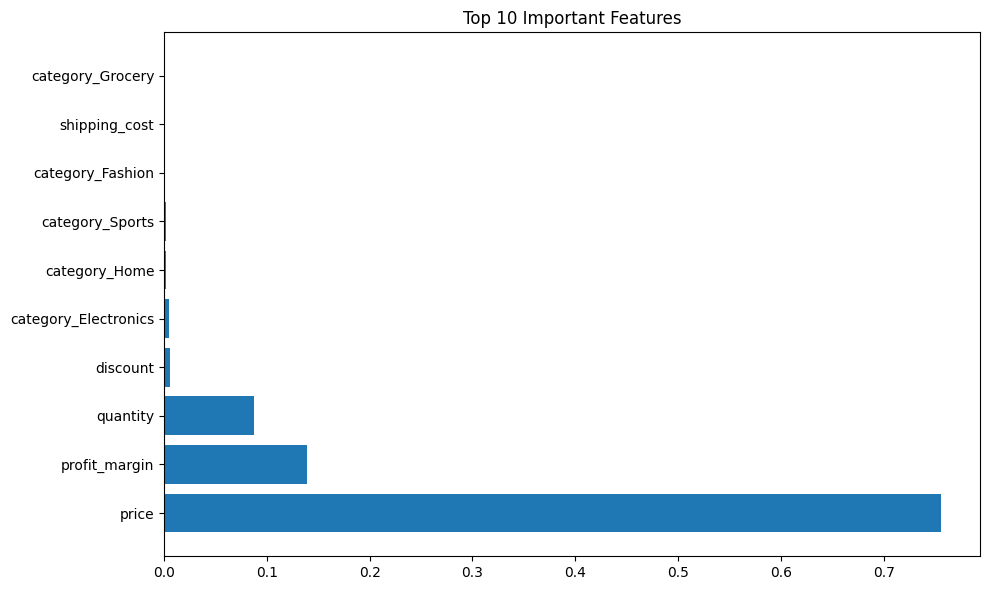

In [41]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.title(
    "Top 10 Important Features"
)

plt.tight_layout()

plt.savefig(
'../Outputs/Feature_Importance.png'
)

plt.show()

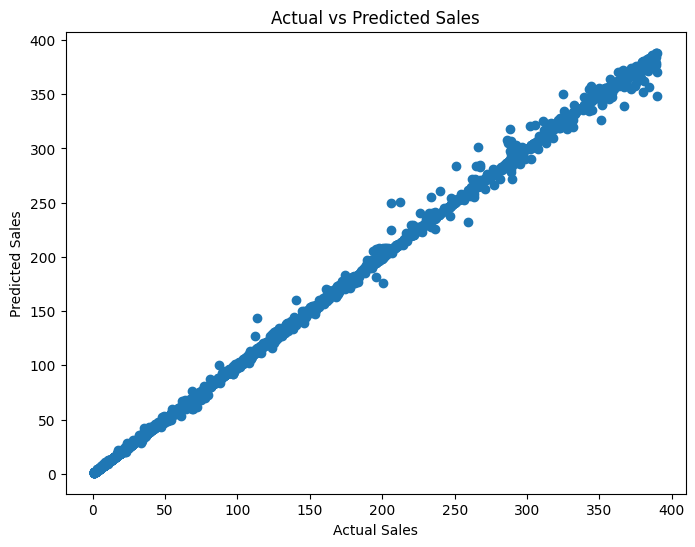

In [ ]:
#Actual Vs Predicted plot
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_pred
)

plt.xlabel(
    "Actual Sales"
)

plt.ylabel(
    "Predicted Sales"
)

plt.title(
    "Actual vs Predicted Sales"
)

plt.savefig(
'../Outputs/Actual_vs_Predicted.png'
)

plt.show()

In [ ]:
# save Best Model
import joblib

joblib.dump(
    best_model,
    r"C:\Users\Admin\OneDrive\DataScience_Internship\DataScience_week2\Task_3_Sales Prediction Model\Model\best_sales_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
